# RAPID-MFA-11: Product substitution

## Descriptions
This module implements product substitution over time in the dynamic model. This is illustrated with the example of cars. We compare two systems: One where only Hybrid Electric Vehicles (HEVs) are used and one where a mix of HEVs and Fuel Cell Vehicles (FCVs) is used. The change from a composition with only HEVs to a composition of both HEVs and FCVs takes place over time. Note that in this example the material composition per car <ins>type</ins> differs, but but within the same car type the material intensity remains stable over time. This is the alternative variation to `RAPID-MFA-11: Type substitution`, where the material composition of each car type changes, but the share of car types remains stable.

### Relations with other RAPID-MFA codes
- This model builds on `RAPID-MFA-9: Switching from products/services to materials with changing material composition`, which is used as the core building block.
- `RAPID-MFA-5: Different lifetime functions`: The code below uses the Weibull lifetime distribution as introduced in module 5. The shape and scale parameters were adapted to the literature source.
- `RAPID-MFA-11: Material substitution`: In this module the car types stay the same but their MI changes, in the type substitution module the car type, which has a different MI, is changed. While they are not the same they can be related, so verify which one fits your specific case.

### Data sources
__Stocks:__ From https://doi.org/10.3390/resources7010009

__Survival curve:__ Weibull distribution, $shape=2.4$, $scale=16.9$, e.g. using `scipy.stats.weibull_min.sf(range(0, len(input_data)), c = 2.428914875, loc = 0, scale = 16.93851375)` Data from https://doi.org/10.3390/resources7010009

__Material intensity:__ In kg/vehicle from Fishman, T., Myers, R.J., Rios, O., Graedel, T.E., 2018. Implications of Emerging Vehicle Technologies on Rare Earth Supply and Demand in the United States.
 Resources 7 (https://doi.org/10.3390/resources7010009)

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__.



## 1. Load libraries

In [1]:
import numpy as np
import scipy.stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Define example input data

In [2]:
# %% 2. Define example input data
input_data = pd.Series([0, 17, 9367, 29639, 65611, 112994, 196655, 405237, 655629, 1002834, 
                        1307203, 1584131, 1836332, 2092277, 2537144, 3074043, 3567853, 4207156, 
                        4945879, 5797925, 6778277, 7902746, 9187646, 10649295, 12303394, 14164318, 
                        16244276, 18552466, 21094228, 23870337, 26876417, 30102657, 33533764, 
                        37149274, 40924083, 44829315, 48833234, 52902345, 57002464, 61099726, 
                        65161509, 69157195, 73058775, 76841335, 80483330, 83966772, 87277263, 
                        90403948, 93339367, 96079253, 98622261, 100969690, 103125124], 
                       name = 'stocks', 
                       index = [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 
                                2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 
                                2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 
                                2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 
                                2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 
                                2048, 2049, 2050])  

# Define the products
products = ["HEV", "FCV"]

# Define the transition start year and the transition end year
transition_timeframe_start = 2031
transition_timeframe_end = 2050

# Create the material intensities dataframe
material_intensities = pd.DataFrame(
    {products[0]: [1056.21065],
     products[1]: [909.50450]},
    index=["aluminium"]
)

# Define the transition timeframe
vehicle_stocks_split_substitution_dict = {
    products[1]: {
        transition_timeframe_start - 1: 0.0,
        transition_timeframe_start: 0.01,
        transition_timeframe_end: 0.3,
    },
    products[0]: {
        transition_timeframe_start - 1: 1.0,
        transition_timeframe_start: 0.99,
        transition_timeframe_end: 0.7,
    },
}

# Parameters for the survival curve
ages = range(0, len(input_data))  
shape = 2.428914875
scale = 16.93851375

### 2.1 Survival curve

In [3]:
survival_curve = scipy.stats.weibull_min.sf(ages, shape, 0, scale)

### 2.2. Vehicle stock transition timeframe

In [4]:
vehicle_stocks_split_substitution = pd.DataFrame(index = input_data.index,
                                                 columns = products)

for product in products:
    if product in vehicle_stocks_split_substitution_dict:
        share_dict = vehicle_stocks_split_substitution_dict[product]

        years = sorted(share_dict.keys())
        shares = [share_dict[year] for year in years]

        vehicle_stocks_split_substitution[product] = np.interp(
            input_data.index,
            years,
            shares
        )

## 3. Run the MFA system

The steps from hereon are a repetition of notebook 2, but with different input data. If you want a more detailed account on how to do this, see notebook 2.

In [5]:
# %% 3. Run the stock-driven model
# %%% 3.1 Set up the MFA system
units = {'time_interval':   'year', 
         'flows_products':  'vehicles/year', 
         'stocks_products': 'vehicles'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.
time_interval = 1
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required
mfa_system_baseline = pd.DataFrame(index = timeframes, columns = ['stocks',
                                                                  'inflows',
                                                                  'outflows',
                                                                  'stock_changes'])

mfa_system_baseline['stocks'] = input_data

# %%% 3.2 Create survival curves matrix
# create survival curves matrix filled with zeros
survival_curve_matrix_baseline = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curve_matrix_baseline.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
   
# %%% 3.3 Create cohorts survival matrix
# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix_baseline = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system_baseline.loc[cohort, 'inflows'] = (
        mfa_system_baseline.loc[cohort, 'stocks'] - cohorts_survival_matrix_baseline.loc[cohort, : cohort - 1].sum()
    ) / survival_curve_matrix_baseline.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix_baseline.loc[:, cohort] = survival_curve_matrix_baseline.loc[:, cohort] * mfa_system_baseline.loc[cohort, 'inflows']
    
# %%% 3.4 Calculate the MFA system
mfa_system_baseline["stock_changes"] = np.diff(mfa_system_baseline["stocks"], prepend=0)
mfa_system_baseline["outflows"] = mfa_system_baseline["inflows"] - mfa_system_baseline["stock_changes"]

## 4. Calculate change of product composition
Fuel cell vehicles (FCV) appear in 2031 and ocupy 30% of the stocks by 2050.

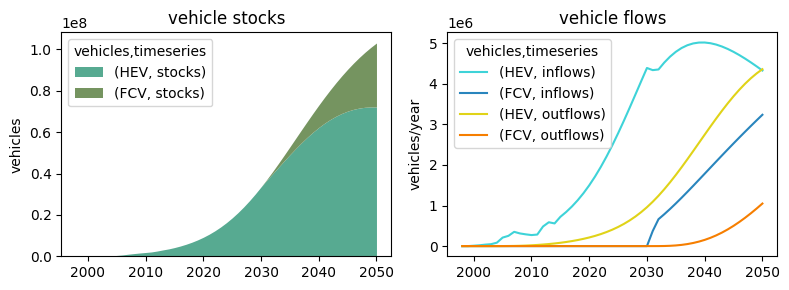

In [7]:
# create an empty multiindex dataframe to hold the results of the MFA for the multi-product (vehicles) layer
mfa_system_substitution_products = pd.DataFrame(index = timeframes,
                                              columns = pd.MultiIndex.from_product([products, 
                                                                                    mfa_system_baseline.columns], 
                                                                                    names=["vehicles", "timeseries"]))
cohorts_survival_matrices = {}

for product in products:
    mfa_system_substitution_products[(product, 'stocks')] = mfa_system_baseline['stocks'] * vehicle_stocks_split_substitution[product]

    # Create cohorts survival matrix
    cohorts_survival_matrices[product] = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)
    for cohort in cohorts:
        mfa_system_substitution_products.loc[cohort, (product, 'inflows')] = (
        mfa_system_substitution_products.loc[cohort, (product,'stocks')] - cohorts_survival_matrices[product].loc[cohort, : cohort - 1].sum()
    ) / survival_curve_matrix_baseline.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
        cohorts_survival_matrices[product].loc[:, cohort] = survival_curve_matrix_baseline.loc[:, cohort] * mfa_system_substitution_products.loc[cohort, (product, 'inflows')]
    
    # Calculate stocks, stock changes, and outflows
    mfa_system_substitution_products[(product, 'stock_changes')] = np.diff(mfa_system_substitution_products[(product, 'stocks')], prepend=0)
    mfa_system_substitution_products[(product, 'outflows')] = mfa_system_substitution_products[(product, 'inflows')] - mfa_system_substitution_products[(product, 'stock_changes')]

# visualize the results of the MFA for vehicles
mfa_system_substitution_products_fig, mfa_system_substitution_products_ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 3), tight_layout=True)
mfa_system_substitution_products.loc[:, (slice(None), 'stocks')].plot(ylabel=units['stocks_products'], 
                                                                    kind="area", 
                                                                    color=["#57AA91", "#759460"], 
                                                                    title="vehicle stocks", 
                                                                    ax=mfa_system_substitution_products_ax[0],
                                                                    linewidth = 0)

mfa_system_substitution_products.loc[:, (slice(None), ['inflows', 'outflows'])].plot(ylabel=units['flows_products'], 
                                                                                   color=["#3ED3D8", "#2985BD", "#E0D318", "#F67E00"], 
                                                                                   title="vehicle flows", 
                                                                                   ax=mfa_system_substitution_products_ax[1]);
